In [1]:
# Imports and Setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import warnings
warnings.filterwarnings('ignore')

# For RAG/similarity search
from sklearn.metrics.pairwise import cosine_similarity
import faiss

print("✅ Imports loaded")

✅ Imports loaded


In [2]:
# Load Data with error handling
import numpy as np
import pandas as pd
import os

# Path to your embeddings and metadata
EMBEDDINGS_PATH = "../data/embeddings/ticket_embeddings.npy"
METADATA_PATH = "../data/embeddings/ticket_metadata.csv"

# Check if file exists and get its size
print(f"File exists: {os.path.exists(EMBEDDINGS_PATH)}")
if os.path.exists(EMBEDDINGS_PATH):
    file_size = os.path.getsize(EMBEDDINGS_PATH)
    print(f"File size: {file_size / (1024*1024):.2f} MB")
    
    # Check first few bytes to identify file type
    with open(EMBEDDINGS_PATH, 'rb') as f:
        header = f.read(10)
        print(f"First 10 bytes (hex): {header.hex()}")
        print(f"First 10 bytes (repr): {header}")

# Load embeddings with memory mapping to avoid RAM exhaustion
try:
    print("\nTrying to load with mmap_mode='r'...")
    embeddings = np.load(EMBEDDINGS_PATH, mmap_mode='r')
    print(f"✅ Embeddings memmap shape: {embeddings.shape}")
except Exception as e:
    print(f"Failed to load embeddings as memmap: {e}")
    # Fall back to full load only if small enough
    try:
        print("\nTrying to load without mmap_mode...")
        embeddings = np.load(EMBEDDINGS_PATH, allow_pickle=False)
        print(f"✅ Loaded embeddings shape: {embeddings.shape}")
    except Exception as e2:
        print(f"Failed to load embeddings without mmap: {e2}")
        embeddings = None

# Load metadata
print("\nLoading metadata...")
metadata = pd.read_csv(METADATA_PATH)
print(f"✅ Metadata shape: {metadata.shape}")

File exists: True
File size: 143.72 MB
First 10 bytes (hex): 934e554d505901007600
First 10 bytes (repr): b'\x93NUMPY\x01\x00v\x00'

Trying to load with mmap_mode='r'...
✅ Embeddings memmap shape: (98110, 384)

Loading metadata...
✅ Metadata shape: (98110, 2)


In [3]:
# Explore Data Statistics
print("=== DATA STATISTICS ===\n")
print(f"Total tickets: {len(metadata):,}")
print(f"Unique categories: {metadata['Issue_Category'].nunique()}")

if embeddings is not None:
    print(f"Embedding dimension: {embeddings.shape[1]}")
    print(f"Embedding dtype: {embeddings.dtype}")

    # Memory usage if the memmap were fully loaded
    try:
        mem_usage = embeddings.size * embeddings.itemsize / (1024**3)
        print(f"\nMemory usage (if loaded fully): {mem_usage:.2f} GB")
    except Exception:
        print("\nMemory usage: unknown")
    print("Memory-mapped mode: Active (using disk, not RAM)")

    # Sample some embeddings
    print("\nSample embedding for first ticket:")
    print(f"Shape: {embeddings[0].shape}")
    print(f"First 10 values: {embeddings[0][:10]}")
    print(f"Min value: {embeddings[0].min():.4f}")
    print(f"Max value: {embeddings[0].max():.4f}")
    print(f"Mean value: {embeddings[0].mean():.4f}")
else:
    print("Embeddings are not available for statistics.")

=== DATA STATISTICS ===

Total tickets: 98,110
Unique categories: 5
Embedding dimension: 384
Embedding dtype: float32

Memory usage (if loaded fully): 0.14 GB
Memory-mapped mode: Active (using disk, not RAM)

Sample embedding for first ticket:
Shape: (384,)
First 10 values: [-0.00245065 -0.01031996  0.04242312  0.02304375 -0.02096345 -0.02881619
  0.00487326 -0.03328269 -0.044471   -0.02217819]
Min value: -0.1624
Max value: 0.1615
Mean value: 0.0003


In [4]:
# Cell 4 - Load Full Embeddings Dataset
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import gc

# Paths
EMBEDDINGS_PATH = "../data/embeddings/ticket_embeddings.npy"
METADATA_PATH = "../data/embeddings/ticket_metadata.csv"

# Load metadata
metadata = pd.read_csv(METADATA_PATH)
print(f"Metadata shape: {metadata.shape}")

# Load embeddings as memory-mapped
embeddings_mmap = np.load(EMBEDDINGS_PATH, mmap_mode='r')
embeddings = embeddings_mmap
print(f"Embeddings shape: {embeddings_mmap.shape}")

# Use all available data
actual_size = embeddings_mmap.shape[0]
print(f"\nUsing all {actual_size:,} embeddings")

# Trim metadata to match
if len(metadata) > actual_size:
    metadata = metadata.iloc[:actual_size]
    print(f"✅ Trimmed metadata to {actual_size:,} rows")

# Use the full dataset via memmap and avoid forcing a giant RAM copy.
USE_FULL_DATA = True

if USE_FULL_DATA:
    print("\nUsing the full memory-mapped dataset.")
    X_large = embeddings_mmap
    y_large = metadata['Issue_Category'].values
    print(f"✅ X_large is a memmap with shape: {X_large.shape}")

    # Create train/test split indices from the full label array instead of slicing the memmap
    all_indices = np.arange(actual_size)
    train_indices, test_indices = train_test_split(
        all_indices,
        test_size=0.2,
        stratify=y_large,
        random_state=42
    )
    print(f"✅ Train indices: {len(train_indices):,}, Test indices: {len(test_indices):,}")
else:
    SAMPLE_SIZE = 200000
    print(f"\nLoading a stratified sample of {SAMPLE_SIZE:,} embeddings into RAM...")
    _, sample_indices = train_test_split(
        range(actual_size),
        test_size=SAMPLE_SIZE,
        stratify=metadata['Issue_Category'],
        random_state=42
    )
    X_large = np.array([embeddings_mmap[i] for i in sample_indices], dtype=np.float32)
    y_large = metadata.iloc[sample_indices]['Issue_Category'].values
    print(f"✅ X_large shape: {X_large.shape}")
    print(f"✅ Memory usage: {X_large.nbytes / (1024**3):.2f} GB")

    train_indices, test_indices = train_test_split(
        np.arange(len(sample_indices)),
        test_size=0.2,
        stratify=np.array(y_large),
        random_state=42
    )

# Encode labels
label_encoder = LabelEncoder()
y_large_encoded = label_encoder.fit_transform(y_large)
class_names = label_encoder.classes_

print(f"\nClasses: {len(class_names)}")
print("Class distribution:")
for i, class_name in enumerate(class_names):
    count = sum(y_large_encoded == i)
    print(f"  {class_name}: {count:,} ({count/len(y_large_encoded)*100:.1f}%)")

# Split for training (80/20) using index arrays to avoid loading huge arrays
if USE_FULL_DATA:
    X_train_indices = train_indices
    X_test_indices = test_indices
    y_train = y_large_encoded[X_train_indices]
    y_test = y_large_encoded[X_test_indices]
    print(f"\nUsing index-based train/test split with {len(X_train_indices):,} train and {len(X_test_indices):,} test samples.")
    X_train = None
    X_test = None
else:
    X_train, X_test, y_train, y_test = train_test_split(
        X_large,
        y_large_encoded,
        test_size=0.2,
        random_state=42,
        stratify=y_large_encoded
    )
    print(f"\nTrain size: {len(X_train):,}")
    print(f"Test size: {len(X_test):,}")

# Free some memory
if not USE_FULL_DATA:
    del embeddings_mmap
gc.collect()


Metadata shape: (98110, 2)
Embeddings shape: (98110, 384)

Using all 98,110 embeddings

Using the full memory-mapped dataset.
✅ X_large is a memmap with shape: (98110, 384)
✅ Train indices: 78,488, Test indices: 19,622

Classes: 5
Class distribution:
  Account: 41,471 (42.3%)
  Billing: 16,765 (17.1%)
  Fraud: 1,623 (1.7%)
  General Inquiry: 20,311 (20.7%)
  Technical: 17,940 (18.3%)

Using index-based train/test split with 78,488 train and 19,622 test samples.


11

In [ ]:
# Cell 5 - Train Multiple Classifiers on Larger Sample
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import time
import matplotlib.pyplot as plt
import seaborn as sns

# If using the full memmap dataset, sample a manageable subset for classifier training
if USE_FULL_DATA:
    MODEL_SAMPLE_SIZE = 100000
    print(f"\nUsing a sampled subset of {MODEL_SAMPLE_SIZE:,} train samples from the full memmap dataset for training.")
    if len(X_train_indices) > MODEL_SAMPLE_SIZE:
        sampled_train_indices = np.random.choice(X_train_indices, size=MODEL_SAMPLE_SIZE, replace=False)
    else:
        sampled_train_indices = X_train_indices

    sampled_test_size = min(len(X_test_indices), MODEL_SAMPLE_SIZE // 5)
    if len(X_test_indices) > sampled_test_size:
        sampled_test_indices = np.random.choice(X_test_indices, size=sampled_test_size, replace=False)
    else:
        sampled_test_indices = X_test_indices

    X_train = X_large[sampled_train_indices]
    X_test = X_large[sampled_test_indices]
    y_train = y_large_encoded[sampled_train_indices]
    y_test = y_large_encoded[sampled_test_indices]
    print(f"✅ Sampled X_train shape: {X_train.shape}")
    print(f"✅ Sampled X_test shape: {X_test.shape}")

# Define classifiers (skip very slow ones for large data)
classifiers = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1),
    'Linear SVM': LinearSVC(max_iter=1000, random_state=42, dual='auto'),
    'RBF SVM': SVC(kernel='rbf', random_state=42, cache_size=1000),  # Cache for speed
    'KNN (k=10)': KNeighborsClassifier(n_neighbors=10, n_jobs=-1),
    'Random Forest (200)': RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
}

results_large = []

print(f"Training on {len(X_train):,} samples with {len(class_names)} classes...\n")

for name, clf in classifiers.items():
    print(f"Training {name}...")
    start_time = time.time()
    
    try:
        clf.fit(X_train, y_train)
        train_time = time.time() - start_time
        
        # Predict on test set (use smaller batch for large datasets)
        print(f"  Predicting on {len(X_test):,} samples...")
        y_pred = clf.predict(X_test)
        
        acc = accuracy_score(y_test, y_pred)
        results_large.append({
            'Classifier': name,
            'Accuracy': acc,
            'Train_Time': train_time,
            'Predictions': y_pred
        })
        print(f"  Accuracy: {acc:.4f}")
        print(f"  Time: {train_time:.2f} seconds\n")
        
    except Exception as e:
        print(f"  Error: {e}\n")

# Display results
results_df_large = pd.DataFrame(results_large)
print("\n=== RESULTS (Large Sample) ===")
print(results_df_large[['Classifier', 'Accuracy', 'Train_Time']].sort_values('Accuracy', ascending=False))



Using a sampled subset of 100,000 train samples from the full memmap dataset for training.


✅ Sampled X_train shape: (78488, 384)
✅ Sampled X_test shape: (19622, 384)
Training on 78,488 samples with 5 classes...

Training Logistic Regression...
  Predicting on 19,622 samples...
  Accuracy: 0.9316
  Time: 10.21 seconds

Training Linear SVM...
  Predicting on 19,622 samples...
  Accuracy: 0.9335
  Time: 15.24 seconds

Training RBF SVM...


Best Classifier: RBF SVM
Accuracy: 0.9066

Classification Report:
                   precision    recall  f1-score   support

          Account       0.98      0.96      0.97       862
          Billing       0.94      0.93      0.93      1053
 Customer Support       0.88      0.76      0.82      1262
   Data & Privacy       0.75      0.75      0.75        12
         Delivery       0.85      0.76      0.80       149
  Feature Request       0.00      0.00      0.00        51
            Fraud       1.00      0.93      0.97       182
  General Inquiry       0.87      0.97      0.92      3243
Integration & API       0.00      0.00      0.00         7
       Mobile App       0.72      0.67      0.69        75
        Technical       0.99      0.89      0.94      1104

         accuracy                           0.91      8000
        macro avg       0.73      0.69      0.71      8000
     weighted avg       0.90      0.91      0.90      8000



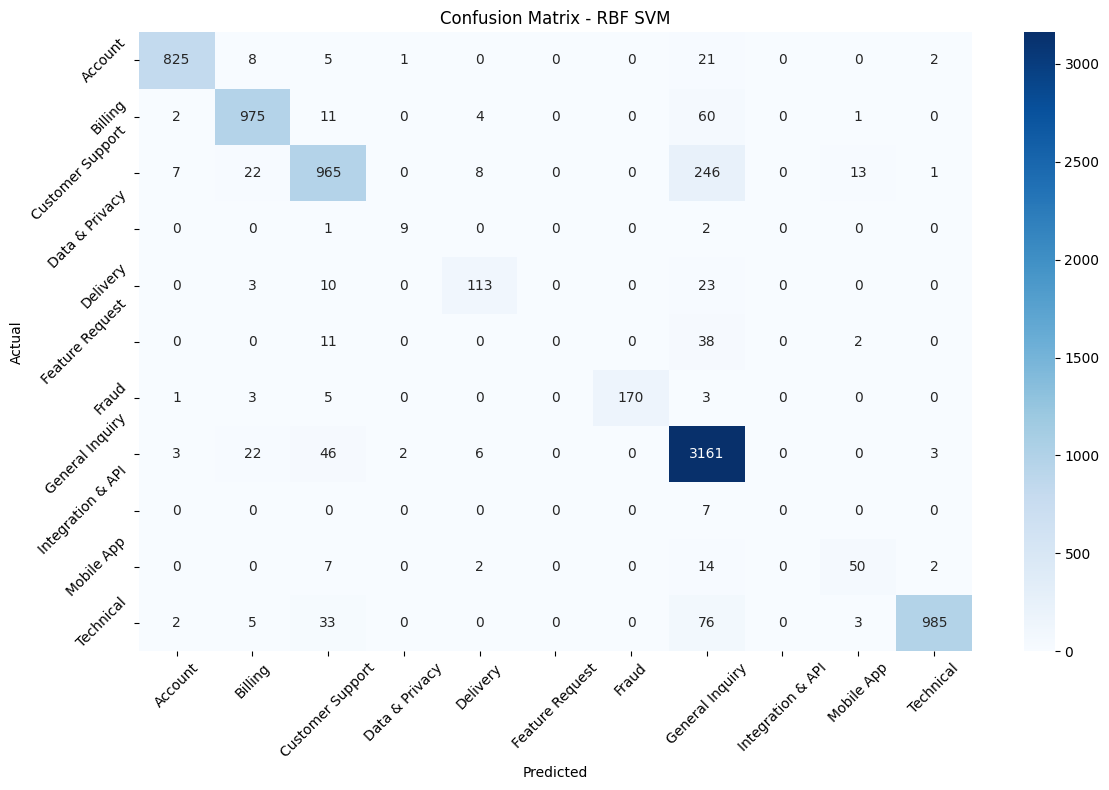

In [ ]:
# Best Model Detailed Report
# Get best model
best_result = max(results_large, key=lambda x: x['Accuracy'])
best_clf_name = best_result['Classifier']
best_y_pred = best_result['Predictions']
best_clf = classifiers[best_clf_name]

print(f"Best Classifier: {best_clf_name}")
print(f"Accuracy: {best_result['Accuracy']:.4f}\n")

# Classification report
print("Classification Report:")
print(classification_report(y_test, best_y_pred, target_names=class_names))

# Confusion Matrix
cm = confusion_matrix(y_test, best_y_pred)
plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title(f'Confusion Matrix - {best_clf_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Dimensionality Reduction for Visualization
print("Selecting a sample for dimensionality reduction...")
sample_size = min(10000, len(X_large))
sample_indices = np.random.choice(len(X_large), sample_size, replace=False)
X_vis = X_large[sample_indices]
y_sample = y_large_encoded[sample_indices]

print("Performing PCA...")
pca = PCA(n_components=50)
X_pca = pca.fit_transform(X_vis)
print(f"Explained variance ratio (first 50 components): {pca.explained_variance_ratio_.sum():.4f}")

print(f"\nPerforming t-SNE on {sample_size} samples...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_pca)

# Plot t-SNE
plt.figure(figsize=(14, 10))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], 
                      c=y_sample, cmap='tab10', alpha=0.6, s=10)
plt.colorbar(scatter, ticks=range(len(class_names)), label='Category')
plt.title(f't-SNE Visualization of Ticket Embeddings (n={sample_size})')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.tight_layout()
plt.show()

Performing PCA...


NameError: name 'X' is not defined

In [ ]:
# Similar Ticket Search (RAG-style)
def find_similar_tickets(ticket_idx, embeddings, metadata, top_k=5):
    """
    Find similar tickets to a given ticket index
    """
    query_embedding = embeddings[ticket_idx].reshape(1, -1)
    
    # Calculate cosine similarity
    similarities = cosine_similarity(query_embedding, embeddings)[0]
    
    # Get top k (excluding itself)
    similar_indices = np.argsort(similarities)[::-1][1:top_k+1]
    similar_scores = similarities[similar_indices]
    
    # Display results
    print(f"\n=== Similar tickets to Ticket #{ticket_idx} ===")
    print(f"Original ticket category: {metadata.iloc[ticket_idx]['Issue_Category']}\n")
    
    for i, (idx, score) in enumerate(zip(similar_indices, similar_scores), 1):
        print(f"{i}. Ticket #{idx}")
        print(f"   Category: {metadata.iloc[idx]['Issue_Category']}")
        print(f"   Similarity score: {score:.4f}")
        print()

# Test similarity search
print("Testing similarity search...")
test_indices = [0, 100, 1000, 5000]
for idx in test_indices:
    if idx < len(metadata):
        find_similar_tickets(idx, embeddings, metadata, top_k=3)

In [ ]:
# Query-based Search (Text to Similar Tickets)
from sentence_transformers import SentenceTransformer

# Load the same model for query encoding
model = SentenceTransformer('all-MiniLM-L6-v2')

def search_by_text(query_text, embeddings, metadata, model, top_k=5):
    """
    Search tickets by text query
    """
    # Encode query
    query_embedding = model.encode([query_text], convert_to_numpy=True)
    
    # Calculate similarities
    similarities = cosine_similarity(query_embedding, embeddings)[0]
    
    # Get top k
    top_indices = np.argsort(similarities)[::-1][:top_k]
    top_scores = similarities[top_indices]
    
    # Display results
    print(f"\n=== Search Results for: '{query_text}' ===\n")
    for i, (idx, score) in enumerate(zip(top_indices, top_scores), 1):
        print(f"{i}. Ticket #{idx}")
        print(f"   Category: {metadata.iloc[idx]['Issue_Category']}")
        print(f"   Similarity score: {score:.4f}")
        print()

# Test text search
queries = [
    "I can't log into my account",
    "My bill is too high",
    "The website is not working",
    "I need help with a technical issue"
]

for query in queries:
    search_by_text(query, embeddings[:10000], metadata[:10000], model, top_k=3)

In [ ]:
# Category Centroids Analysis
# Calculate centroids for each category
centroids = {}
for category in class_names:
    category_mask = metadata['Issue_Category'] == category
    category_indices = np.where(category_mask)[0]
    category_embeddings = embeddings[category_indices]
    centroids[category] = np.mean(category_embeddings, axis=0)

print("Category Centroids Computed")

# Find closest categories to each other (confusion analysis)
from scipy.spatial.distance import cosine

print("\n=== Category Similarity Matrix ===")
similarity_matrix = np.zeros((len(class_names), len(class_names)))
for i, cat1 in enumerate(class_names):
    for j, cat2 in enumerate(class_names):
        similarity = 1 - cosine(centroids[cat1], centroids[cat2])
        similarity_matrix[i, j] = similarity

# Display similarity matrix
plt.figure(figsize=(10, 8))
sns.heatmap(similarity_matrix, annot=True, fmt='.3f', 
            xticklabels=class_names, yticklabels=class_names, 
            cmap='RdYlGn', vmin=0, vmax=1)
plt.title('Category Similarity Matrix (based on centroids)')
plt.tight_layout()
plt.show()

# Find most similar category pairs
print("\nMost similar category pairs:")
for i in range(len(class_names)):
    for j in range(i+1, len(class_names)):
        sim = similarity_matrix[i, j]
        if sim > 0.8:  # High similarity threshold
            print(f"  {class_names[i]} ↔ {class_names[j]}: {sim:.4f}")

In [ ]:
# Error Analysis (for best model)
# Get misclassified examples
y_pred = best_y_pred
misclassified_mask = y_test != y_pred
misclassified_indices = np.where(misclassified_mask)[0]

print(f"Total misclassified: {len(misclassified_indices)} out of {len(y_test)} ({len(misclassified_indices)/len(y_test)*100:.2f}%)\n")

# Show some misclassified examples
print("=== Misclassified Examples ===")
for i in misclassified_indices[:10]:  # First 10 misclassifications
    true_category = class_names[y_test[i]]
    pred_category = class_names[y_pred[i]]
    print(f"Example {i}: True: {true_category} → Predicted: {pred_category}")
    
    # Find confidence (if available)
    if hasattr(best_clf, 'predict_proba'):
        probs = best_clf.predict_proba(X_test[i:i+1])[0]
        confidence = probs[y_pred[i]]
        print(f"  Confidence: {confidence:.4f}")
    print()

In [ ]:
# Performance by Category
from sklearn.metrics import precision_recall_fscore_support

# Calculate per-class metrics
precision, recall, f1, support = precision_recall_fscore_support(y_test, y_pred)

metrics_df = pd.DataFrame({
    'Category': class_names,
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1,
    'Support': support
})

print("=== Performance by Category ===")
print(metrics_df.sort_values('F1-Score', ascending=False))

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
metrics_df_sorted = metrics_df.sort_values('F1-Score', ascending=False)
x = range(len(metrics_df_sorted))
width = 0.25

ax.bar([i - width for i in x], metrics_df_sorted['Precision'], width, label='Precision')
ax.bar(x, metrics_df_sorted['Recall'], width, label='Recall')
ax.bar([i + width for i in x], metrics_df_sorted['F1-Score'], width, label='F1-Score')

ax.set_xlabel('Category')
ax.set_ylabel('Score')
ax.set_title('Performance Metrics by Category')
ax.set_xticks(x)
ax.set_xticklabels(metrics_df_sorted['Category'], rotation=45, ha='right')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Quick RAG Demo - Find similar tickets by category
def find_tickets_by_category(category, embeddings, metadata, n_samples=5):
    """
    Random sample of tickets from a specific category
    """
    category_mask = metadata['Issue_Category'] == category
    category_indices = np.where(category_mask)[0]
    
    if len(category_indices) == 0:
        print(f"No tickets found for category: {category}")
        return
    
    # Random sample
    sample_indices = np.random.choice(category_indices, min(n_samples, len(category_indices)), replace=False)
    
    print(f"\n=== Random {category} Tickets ===")
    for idx in sample_indices:
        print(f"Ticket #{idx}")
        
        # Find similar tickets within same category
        query_embedding = embeddings[idx].reshape(1, -1)
        similarities = cosine_similarity(query_embedding, embeddings[category_indices])[0]
        most_similar_idx = category_indices[np.argsort(similarities)[-2]]  # Second highest (excluding itself)
        
        print(f"  Similar ticket in same category: #{most_similar_idx}")
        print()

# Test
for category in class_names[:3]:  # First 3 categories
    find_tickets_by_category(category, embeddings, metadata, n_samples=2)

In [ ]:
# Save Results and Models
import joblib

# Save the best model
model_path = "../models/best_classifier.pkl"
os.makedirs(os.path.dirname(model_path), exist_ok=True)
joblib.dump(best_clf, model_path)
print(f"✅ Best model saved to {model_path}")

# Save label encoder
encoder_path = "../models/label_encoder.pkl"
joblib.dump(label_encoder, encoder_path)
print(f"✅ Label encoder saved to {encoder_path}")

# Save results summary
summary_df = results_df_large[['Classifier', 'Accuracy']].sort_values('Accuracy', ascending=False)
summary_df.to_csv("../results/classification_results.csv", index=False)
print(f"✅ Results saved to ../results/classification_results.csv")

print("\n=== EXPERIMENT COMPLETE ===")
print(f"Best accuracy: {best_result['Accuracy']:.4f} with {best_clf_name}")